In [2]:
import sys
from pathlib import Path

# Allow imports from project root
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from src.config import CONFIG, PROJECT_ROOT

# Plotting config
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

COLORS = {
    "aaa_spread": "#1b9e77",
    "aa_spread":  "#7570b3",
    "bbb_spread": "#d95f02",
    "hy_spread":  "#e7298a",
    "vix":        "#666666",
}

FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

In [3]:
df = pd.read_csv(
    PROJECT_ROOT / "data/processed/master_enriched.csv",
    index_col=0, parse_dates=True,
)
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
df.head()

Shape: (6803, 42)
Date range: 2000-06-23 to 2026-03-19


,aaa_spread,aa_spread,bbb_spread,hy_spread,treasury_10y,treasury_5y,vix,aaa_spread_change_1d,aaa_spread_change_5d,aaa_spread_change_20d,...,hy_spread_change_5d,hy_spread_change_20d,hy_spread_zscore_60d,hy_spread_zscore_252d,hy_spread_pctile_252d,hy_spread_rolling_vol_20d,hy_spread_rolling_vol_60d,bbb_hy_ratio,bbb_hy_ratio_change_1d,aa_bbb_ratio
date,,,,,,,,,,,,,,,,,,,,,
2000-06-23,0.99,1.23,2.13,5.99,6.19,6.37,22.34,-0.01,-0.01,0.00,...,-0.20,-0.19,0.215035,0.987132,0.410714,0.040324,0.056561,0.355593,0.002457,0.577465
2000-06-26,1.00,1.24,2.14,6.05,6.11,6.29,22.45,0.01,0.00,0.00,...,-0.13,-0.14,0.557818,1.092657,0.420635,0.043054,0.053190,0.353719,-0.001874,0.579439
2000-06-27,0.98,1.24,2.15,6.05,6.10,6.29,21.80,-0.02,-0.03,-0.02,...,-0.09,-0.10,0.545631,1.083334,0.422619,0.042364,0.053190,0.355372,0.001653,0.576744
2000-06-28,0.98,1.24,2.15,6.04,6.11,6.28,20.29,0.00,-0.02,-0.04,...,-0.03,-0.12,0.470243,1.055421,0.420635,0.042227,0.052360,0.355960,0.000588,0.576744
2000-06-29,0.98,1.25,2.14,6.11,6.04,6.21,19.70,0.00,-0.02,-0.05,...,0.05,-0.11,0.857398,1.178434,0.440476,0.043100,0.052972,0.350245,-0.005715,0.584112


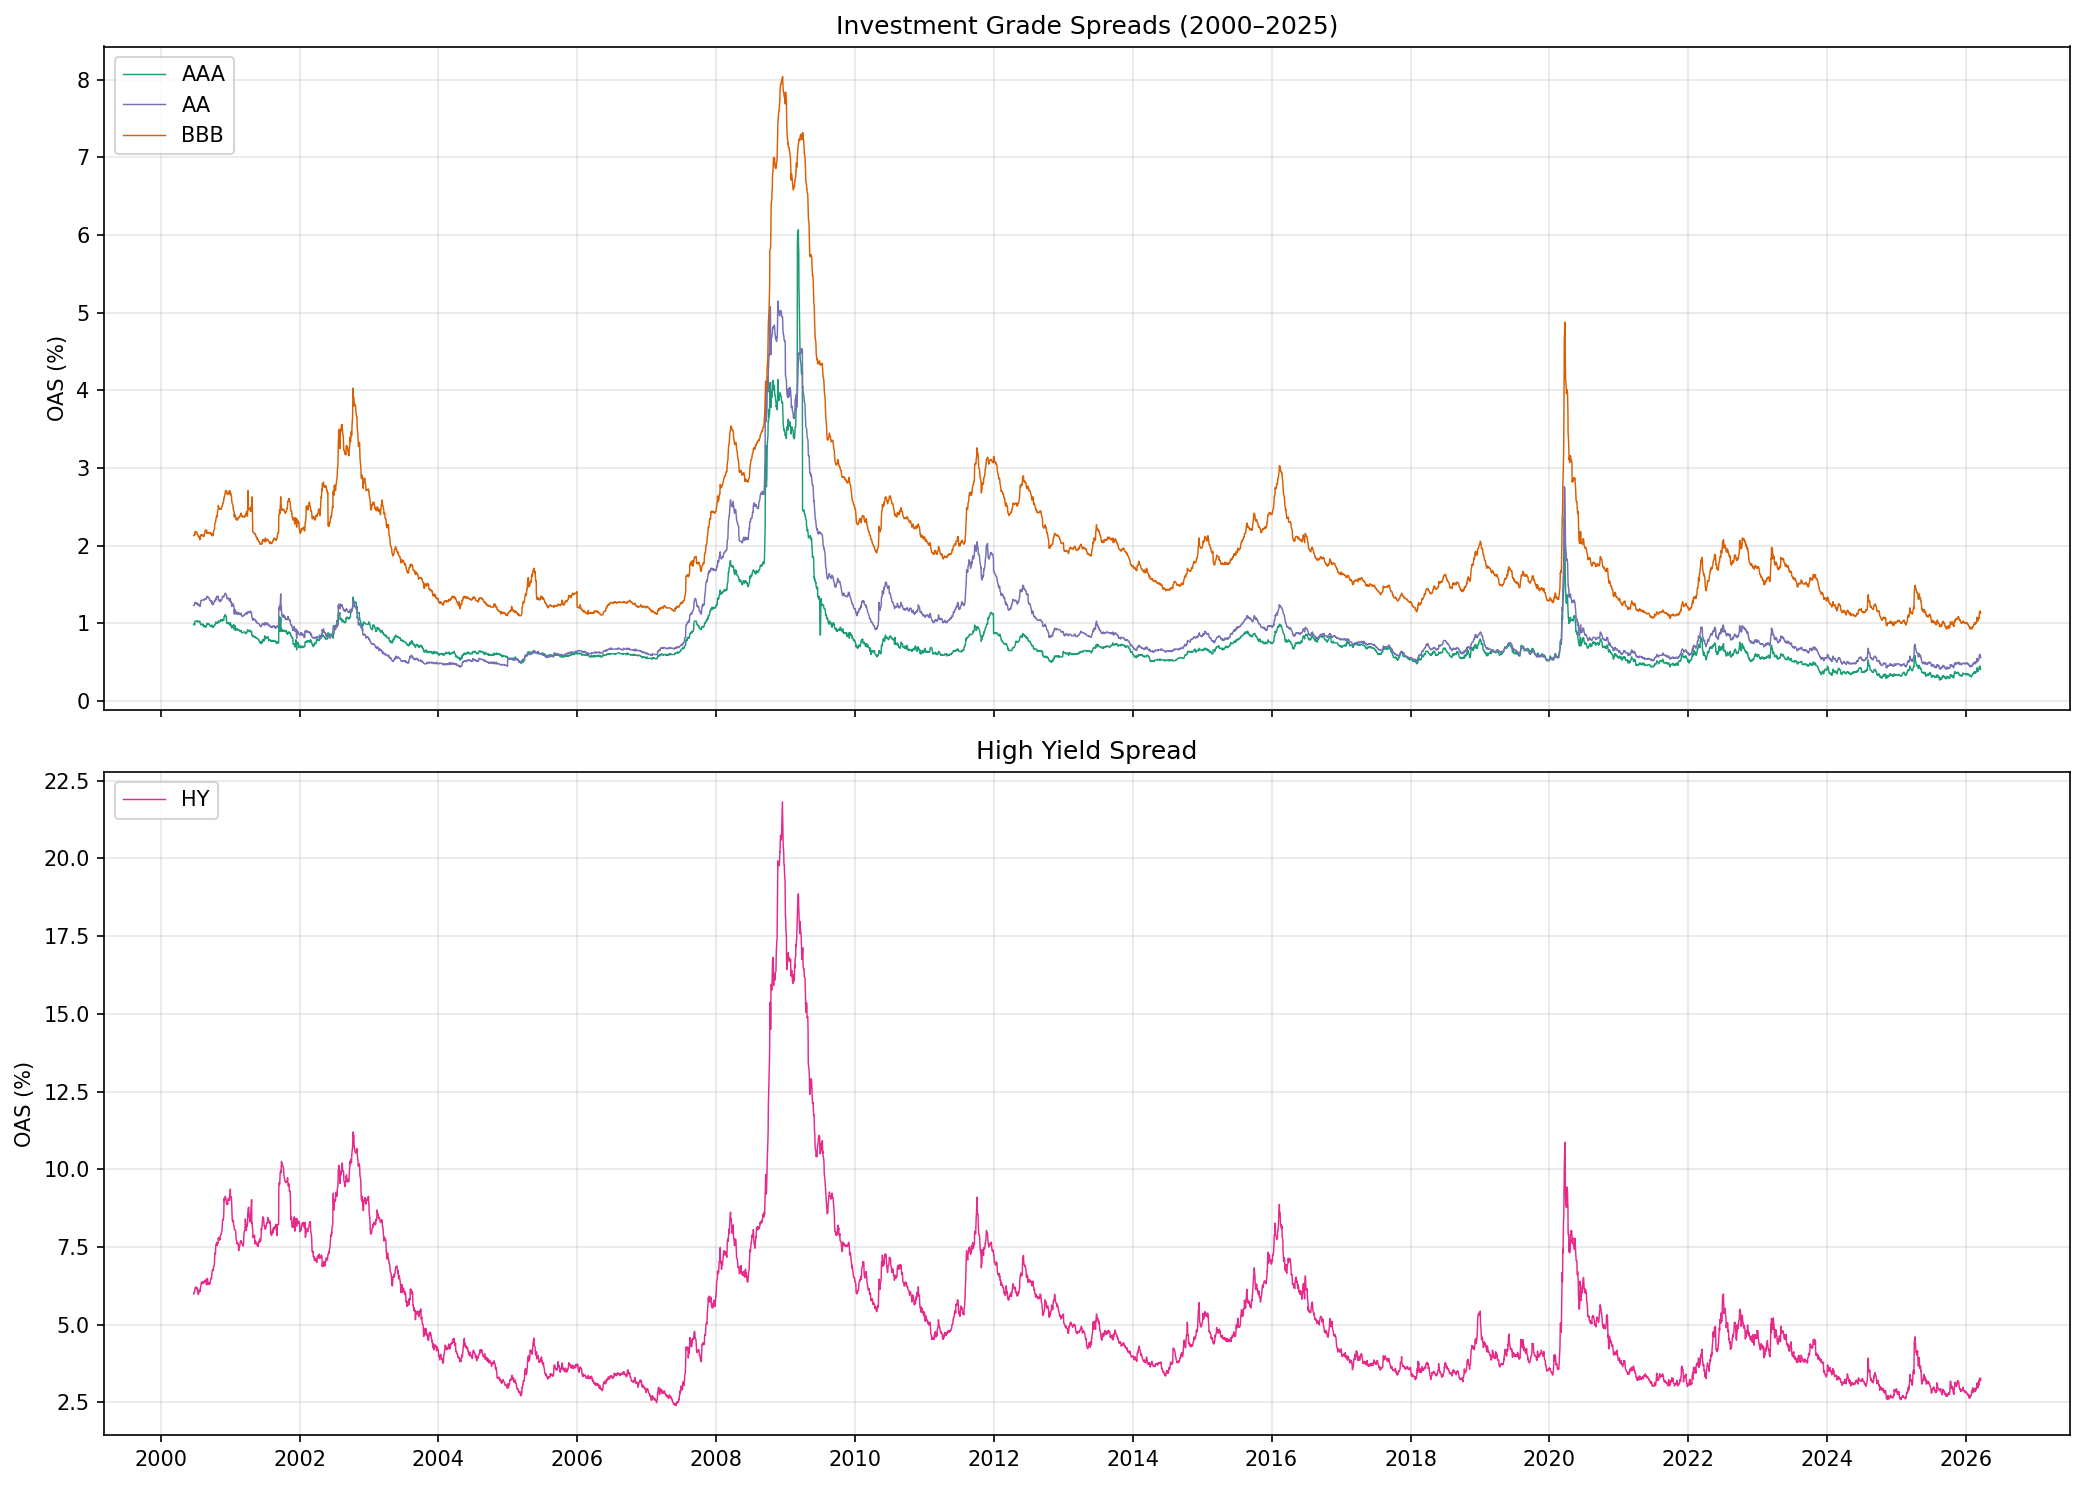

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top: IG spreads
ax1 = axes[0]
for col in ["aaa_spread", "aa_spread", "bbb_spread"]:
    ax1.plot(df.index, df[col], label=col.replace("_spread","").upper(),
             color=COLORS[col], linewidth=0.7)
ax1.set_ylabel("OAS (%)")
ax1.set_title("Investment Grade Spreads (2000–2025)")
ax1.legend(loc="upper left")

# Bottom: HY spread
ax2 = axes[1]
ax2.plot(df.index, df["hy_spread"], label="HY", color=COLORS["hy_spread"], linewidth=0.7)
ax2.set_ylabel("OAS (%)")
ax2.set_title("High Yield Spread")
ax2.legend(loc="upper left")
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
fig.savefig(FIGURES_DIR / "spread_history.png", bbox_inches="tight")
plt.show()